**D206 Data Cleaning Program Assignment**
=

Tatiana Tomanek,
Student ID: 102041742,
Masters of Data Analyst,
D206: Data Cleaning

In [244]:
#importing packages
import pandas as pd
from pandas import DataFrame
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
from sklearn import preprocessing 
from sklearn.decomposition import PCA

In [246]:
#importing the csv file
med = pd.read_csv('/Users/tatom/OneDrive/Desktop/Medicine/medical_raw_data.csv')

In [248]:
#Looking at the top 5 rows
med.head()

,Unnamed: 0,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,...,TotalCharge,Additional_charges,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8
0,1,1,C412403,8cd49b13-f45a-4b47-a2bd-173ffa932c2f,3a83ddb66e2ae73798bdf1d705dc0932,Eva,AL,Morgan,35621,34.34960,...,3191.048774,17939.403420,3,3,2,2,4,3,3,4
1,2,2,Z919181,d2450b70-0337-4406-bdbb-bc1037f1734c,176354c5eef714957d486009feabf195,Marianna,FL,Jackson,32446,30.84513,...,4214.905346,17612.998120,3,4,3,4,4,4,3,3
2,3,3,F995323,a2057123-abf5-4a2c-abad-8ffe33512562,e19a0fa00aeda885b8a436757e889bc9,Sioux Falls,SD,Minnehaha,57110,43.54321,...,2177.586768,17505.192460,2,4,4,4,3,4,3,3
3,4,4,A879973,1dec528d-eb34-4079-adce-0d7a40e82205,cd17d7b6d152cb6f23957346d11c3f07,New Richland,MN,Waseca,56072,43.89744,...,2465.118965,12993.437350,3,5,5,3,4,5,5,5
4,5,5,C544523,5885f56b-d6da-43a3-8760-83583af94266,d2f0425877b10ed6bb381f3e2579424a,West Point,VA,King William,23181,37.59894,...,1885.655137,3716.525786,2,1,3,3,5,3,4,3


In [250]:
#Summary of the data
med.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 53 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          10000 non-null  int64  
 1   CaseOrder           10000 non-null  int64  
 2   Customer_id         10000 non-null  object 
 3   Interaction         10000 non-null  object 
 4   UID                 10000 non-null  object 
 5   City                10000 non-null  object 
 6   State               10000 non-null  object 
 7   County              10000 non-null  object 
 8   Zip                 10000 non-null  int64  
 9   Lat                 10000 non-null  float64
 10  Lng                 10000 non-null  float64
 11  Population          10000 non-null  int64  
 12  Area                10000 non-null  object 
 13  Timezone            10000 non-null  object 
 14  Job                 10000 non-null  object 
 15  Children            7412 non-null   float64
 16  Age  

**Re-expressing Data by Label Encoding**

In [252]:
#Setting up label_encoder to help re-express the variables using just Yes / No
label_encoder = preprocessing.LabelEncoder() 

In [254]:
#Cheching it using just Yes / No
med['ReAdmis'].unique()

array(['No', 'Yes'], dtype=object)

In [256]:
#Encoding the lables with 0 and 1
med['ReAdmis']= label_encoder.fit_transform(med['ReAdmis']) 
#hecking to make sure that it worked
med['ReAdmis'].unique() 

array([0, 1])

In [258]:
#repeating the previous steps 
med['HighBlood'].unique()

array(['Yes', 'No'], dtype=object)

In [260]:
med['HighBlood']= label_encoder.fit_transform(med['HighBlood']) 
med['HighBlood'].unique() 

array([1, 0])

In [262]:
med['Stroke'].unique()

array(['No', 'Yes'], dtype=object)

In [264]:
med['Stroke']= label_encoder.fit_transform(med['Stroke']) 
med['Stroke'].unique()

array([0, 1])

In [266]:
med['Arthritis'].unique()

array(['Yes', 'No'], dtype=object)

In [267]:
med['Arthritis']= label_encoder.fit_transform(med['Arthritis']) 
med['Arthritis'].unique()

array([1, 0])

In [268]:
med['Diabetes'].unique()

array(['Yes', 'No'], dtype=object)

In [270]:
med['Diabetes']= label_encoder.fit_transform(med['Diabetes']) 
med['Diabetes'].unique()

array([1, 0])

In [274]:
med['Hyperlipidemia'].unique()

array(['No', 'Yes'], dtype=object)

In [276]:
med['Hyperlipidemia']= label_encoder.fit_transform(med['Hyperlipidemia']) 
med['Hyperlipidemia'].unique()

array([0, 1])

In [292]:
med['BackPain'].unique()

array([1, 0])

In [294]:
med['BackPain']= label_encoder.fit_transform(med['BackPain']) 
med['BackPain'].unique()

array([1, 0], dtype=int64)

In [296]:
med['Allergic_rhinitis'].unique()

array([1, 0])

In [298]:
med['Allergic_rhinitis']= label_encoder.fit_transform(med['Allergic_rhinitis']) 
med['Allergic_rhinitis'].unique()

array([1, 0], dtype=int64)

In [300]:
med['Reflux_esophagitis'].unique()

array([0, 1])

In [302]:
med['Reflux_esophagitis']= label_encoder.fit_transform(med['Reflux_esophagitis']) 
med['Reflux_esophagitis'].unique()

array([0, 1], dtype=int64)

In [304]:
med['Asthma'].unique()

array(['Yes', 'No'], dtype=object)

In [28]:
med['Asthma']= label_encoder.fit_transform(med['Asthma']) 
med['Asthma'].unique()

array([1, 0])

All the variables that just have Yes and no as inputs now have ben re expressed

In [306]:
#Want to remane the last variables to make them more understandable 
med.rename(columns = {'Item1':'TimelyAdmission', 
                      'Item2':'TimelyTreatment',
                      'Item3':'TimelyVisits',
                      'Item4':'Reliability',
                      'Item5':'Options',
                      'Item6':'HoursOfTreatment',
                      'Item7':'CourteousStaff',
                      'Item8':'ActiveListening'},inplace=True)

In [308]:
#checking to make sure that it worked
med.head()

,Unnamed: 0,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,...,TotalCharge,Additional_charges,TimelyAdmission,TimelyTreatment,TimelyVisits,Reliability,Options,HoursOfTreatment,CourteousStaff,ActiveListening
0,1,1,C412403,8cd49b13-f45a-4b47-a2bd-173ffa932c2f,3a83ddb66e2ae73798bdf1d705dc0932,Eva,AL,Morgan,35621,34.34960,...,3191.048774,17939.403420,3,3,2,2,4,3,3,4
1,2,2,Z919181,d2450b70-0337-4406-bdbb-bc1037f1734c,176354c5eef714957d486009feabf195,Marianna,FL,Jackson,32446,30.84513,...,4214.905346,17612.998120,3,4,3,4,4,4,3,3
2,3,3,F995323,a2057123-abf5-4a2c-abad-8ffe33512562,e19a0fa00aeda885b8a436757e889bc9,Sioux Falls,SD,Minnehaha,57110,43.54321,...,2177.586768,17505.192460,2,4,4,4,3,4,3,3
3,4,4,A879973,1dec528d-eb34-4079-adce-0d7a40e82205,cd17d7b6d152cb6f23957346d11c3f07,New Richland,MN,Waseca,56072,43.89744,...,2465.118965,12993.437350,3,5,5,3,4,5,5,5
4,5,5,C544523,5885f56b-d6da-43a3-8760-83583af94266,d2f0425877b10ed6bb381f3e2579424a,West Point,VA,King William,23181,37.59894,...,1885.655137,3716.525786,2,1,3,3,5,3,4,3


**Looking for duplicates**

In [310]:
#Checking for exact duplicates 
print(med.duplicated().value_counts())
# No duplicates

False    10000
Name: count, dtype: int64


In [312]:
#Checking for consistency within the categotical variables by looking at each unique input
med['Area'].unique()

array(['Suburban', 'Urban', 'Rural'], dtype=object)

In [314]:
med['Timezone'].unique()

array(['America/Chicago', 'America/New_York', 'America/Los_Angeles',
       'America/Indiana/Indianapolis', 'America/Detroit',
       'America/Denver', 'America/Nome', 'America/Anchorage',
       'America/Phoenix', 'America/Boise', 'America/Puerto_Rico',
       'America/Yakutat', 'Pacific/Honolulu', 'America/Menominee',
       'America/Kentucky/Louisville', 'America/Indiana/Vincennes',
       'America/Toronto', 'America/Indiana/Marengo',
       'America/Indiana/Winamac', 'America/Indiana/Tell_City',
       'America/Sitka', 'America/Indiana/Knox',
       'America/North_Dakota/New_Salem', 'America/Indiana/Vevay',
       'America/Adak', 'America/North_Dakota/Beulah'], dtype=object)

In [316]:
med['Job'].unique()

array(['Psychologist, sport and exercise', 'Community development worker',
       'Chief Executive Officer', 'Early years teacher',
       'Health promotion specialist', 'Corporate treasurer',
       'Hydrologist', 'Psychiatric nurse', 'Computer games developer',
       'Production assistant, radio', 'Contractor',
       'Surveyor, planning and development',
       'English as a second language teacher', 'Actuary', 'Media planner',
       'Fast food restaurant manager', 'Horticulturist, commercial',
       'Secretary, company', 'Designer, graphic', 'Personnel officer',
       'Telecommunications researcher', 'Restaurant manager, fast food',
       'Surveyor, minerals', 'Architectural technologist',
       'Therapist, speech and language', 'Accounting technician',
       'Glass blower/designer', 'Travel agency manager', 'Illustrator',
       'Police officer', 'Accountant, chartered public finance',
       'Sport and exercise psychologist', 'Pensions consultant',
       'Community educat

In [318]:
# Seeing how many unique jobs that is  
len(med['Job'].unique())

639

In [320]:
med['Education'].unique()

array(['Some College, Less than 1 Year',
       'Some College, 1 or More Years, No Degree',
       'GED or Alternative Credential', 'Regular High School Diploma',
       "Bachelor's Degree", "Master's Degree",
       'Nursery School to 8th Grade',
       '9th Grade to 12th Grade, No Diploma', 'Doctorate Degree',
       "Associate's Degree", 'Professional School Degree',
       'No Schooling Completed'], dtype=object)

In [322]:
med['Employment'].unique()

array(['Full Time', 'Retired', 'Unemployed', 'Student', 'Part Time'],
      dtype=object)

In [324]:
med['Marital'].unique()

array(['Divorced', 'Married', 'Widowed', 'Never Married', 'Separated'],
      dtype=object)

In [326]:
med['Gender'].unique()

array(['Male', 'Female', 'Prefer not to answer'], dtype=object)

In [328]:
med['Initial_admin'].unique()

array(['Emergency Admission', 'Elective Admission',
       'Observation Admission'], dtype=object)

In [330]:
med['Services'].unique()

array(['Blood Work', 'Intravenous', 'CT Scan', 'MRI'], dtype=object)

Can say that there are is no duplicates based on the fact there to duplicate function showed 0 and that there are no vartients in
the most of the categorical data

**Finding and Treating Nulls**

In [46]:
#Getting the sum of all nulls in each column
med.isnull().sum()

Unnamed: 0               0
CaseOrder                0
Customer_id              0
Interaction              0
UID                      0
City                     0
State                    0
County                   0
Zip                      0
Lat                      0
Lng                      0
Population               0
Area                     0
Timezone                 0
Job                      0
Children              2588
Age                   2414
Education                0
Employment               0
Income                2464
Marital                  0
Gender                   0
ReAdmis                  0
VitD_levels              0
Doc_visits               0
Full_meals_eaten         0
VitD_supp                0
Soft_drink            2467
Initial_admin            0
HighBlood                0
Stroke                   0
Complication_risk        0
Overweight             982
Arthritis                0
Diabetes                 0
Hyperlipidemia           0
BackPain                 0
A

In [332]:
#Seperating the null rows 
null_rows = med.isnull().any(axis=1)
med[null_rows]

,Unnamed: 0,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,...,TotalCharge,Additional_charges,TimelyAdmission,TimelyTreatment,TimelyVisits,Reliability,Options,HoursOfTreatment,CourteousStaff,ActiveListening
0,1,1,C412403,8cd49b13-f45a-4b47-a2bd-173ffa932c2f,3a83ddb66e2ae73798bdf1d705dc0932,Eva,AL,Morgan,35621,34.34960,...,3191.048774,17939.403420,3,3,2,2,4,3,3,4
1,2,2,Z919181,d2450b70-0337-4406-bdbb-bc1037f1734c,176354c5eef714957d486009feabf195,Marianna,FL,Jackson,32446,30.84513,...,4214.905346,17612.998120,3,4,3,4,4,4,3,3
2,3,3,F995323,a2057123-abf5-4a2c-abad-8ffe33512562,e19a0fa00aeda885b8a436757e889bc9,Sioux Falls,SD,Minnehaha,57110,43.54321,...,2177.586768,17505.192460,2,4,4,4,3,4,3,3
3,4,4,A879973,1dec528d-eb34-4079-adce-0d7a40e82205,cd17d7b6d152cb6f23957346d11c3f07,New Richland,MN,Waseca,56072,43.89744,...,2465.118965,12993.437350,3,5,5,3,4,5,5,5
4,5,5,C544523,5885f56b-d6da-43a3-8760-83583af94266,d2f0425877b10ed6bb381f3e2579424a,West Point,VA,King William,23181,37.59894,...,1885.655137,3716.525786,2,1,3,3,5,3,4,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9986,9987,9987,Z630066,1ed0ed27-4965-4252-85ea-dd7ed73bd51a,f132eca4af3b1c955d89a213096ef88a,Perry,IA,Dallas,50220,41.83609,...,6476.178435,15591.407940,3,3,3,3,4,4,4,3
9990,9991,9991,M07341,9b73f4cb-3945-41c1-9a38-129fcecde3a0,4f83c32e349fa29482f338ed25896f01,Crosby,MS,Wilkinson,39633,31.29102,...,6900.208499,11365.374050,3,4,4,4,4,4,3,3
9995,9996,9996,B863060,a25b594d-0328-486f-a9b9-0567eb0f9723,39184dc28cc038871912ccc4500049e5,Norlina,NC,Warren,27563,36.42886,...,6651.241294,8927.642189,3,2,2,3,4,3,4,2
9997,9998,9998,R778890,1d79569d-8e0f-4180-a207-d67ee4527d26,41b770aeee97a5b9e7f69c906a8119d7,Southside,TN,Montgomery,37171,36.36655,...,7725.953391,15281.214660,3,3,3,4,4,2,3,2


In [334]:
#Examining the distribution of the numeric null variables to see how to fill the null

In [336]:
med.Children.describe()

count    7412.000000
mean        2.098219
std         2.155427
min         0.000000
25%         0.000000
50%         1.000000
75%         3.000000
max        10.000000
Name: Children, dtype: float64

(array([1880., 1858., 1094., 1113.,  739.,  126.,  145.,  154.,  157.,
         146.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.]),
 <BarContainer object of 10 artists>)

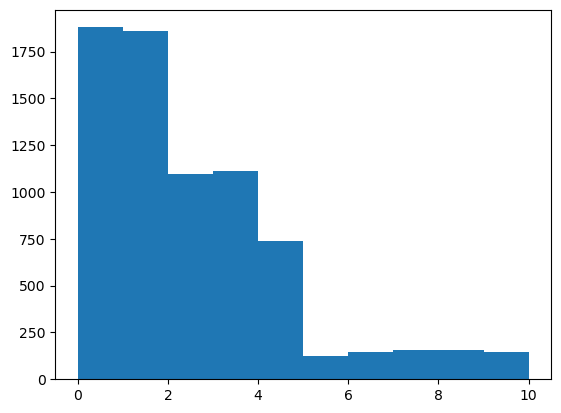

In [338]:
plt.hist(med['Children'])

In [51]:
#Children is positively shewed so it would be best to be filled with the median 

In [340]:
med.Age.describe()

count    7586.000000
mean       53.295676
std        20.659182
min        18.000000
25%        35.000000
50%        53.000000
75%        71.000000
max        89.000000
Name: Age, dtype: float64

(array([823., 761., 746., 753., 746., 739., 730., 765., 710., 813.]),
 array([18. , 25.1, 32.2, 39.3, 46.4, 53.5, 60.6, 67.7, 74.8, 81.9, 89. ]),
 <BarContainer object of 10 artists>)

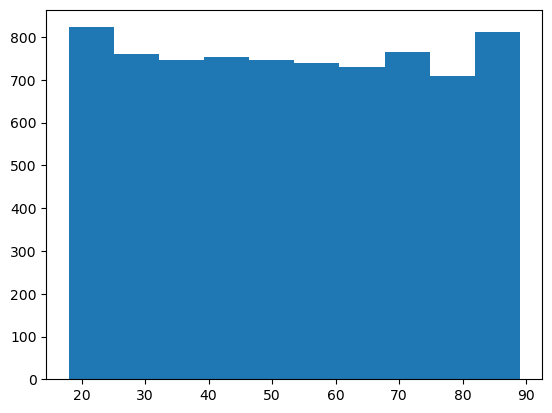

In [342]:
plt.hist(med['Age'])

In [344]:
# Age has a uniform distribution so should be filled with mean

In [346]:
med.Income.describe()

count      7536.000000
mean      40484.438268
std       28664.861050
min         154.080000
25%       19450.792500
50%       33942.280000
75%       54075.235000
max      207249.130000
Name: Income, dtype: float64

(array([2068., 2526., 1532.,  790.,  340.,  156.,   67.,   34.,   12.,
          11.]),
 array([1.54080000e+02, 2.08635850e+04, 4.15730900e+04, 6.22825950e+04,
        8.29921000e+04, 1.03701605e+05, 1.24411110e+05, 1.45120615e+05,
        1.65830120e+05, 1.86539625e+05, 2.07249130e+05]),
 <BarContainer object of 10 artists>)

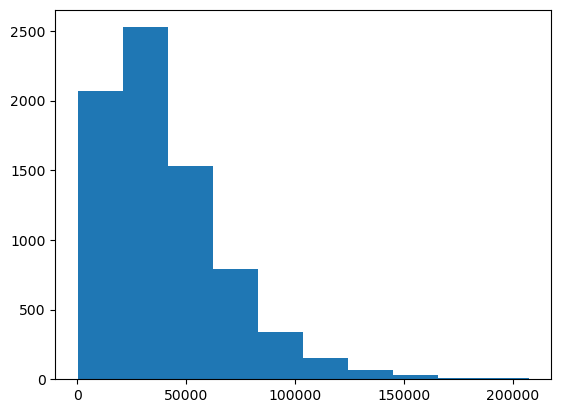

In [348]:
plt.hist(med['Income'])

In [350]:
#Income is positively shewed so it should be best to be filled with the median 

In [352]:
med.Initial_days.describe() 

count    8944.000000
mean       34.432082
std        26.287050
min         1.001981
25%         7.911709
50%        34.446941
75%        61.124654
max        71.981486
Name: Initial_days, dtype: float64

(array([2288., 1429.,  599.,  134.,   32.,  235.,  502.,  916., 1314.,
        1495.]),
 array([ 1.00198092,  8.09993146, 15.197882  , 22.29583253, 29.39378307,
        36.49173361, 43.58968415, 50.68763469, 57.78558522, 64.88353576,
        71.9814863 ]),
 <BarContainer object of 10 artists>)

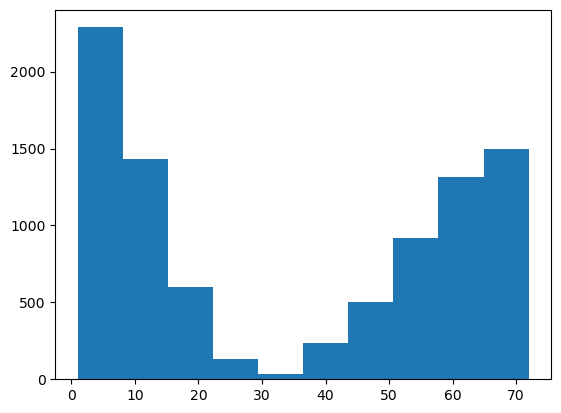

In [354]:
plt.hist(med['Initial_days'])

In [60]:
#Initial_days is bimodal so have to see either median or mode works best 

In [356]:
#Now filling all the numerical nulls 

In [358]:
null_rows['Children'] = med.fillna({'Children': med['Children'].median() }, inplace=True)

In [360]:
null_rows['Age'] = med.fillna({'Age': med['Age'].mean() }, inplace=True)

In [362]:
null_rows['Income'] = med.fillna({'Income': med['Income'].median() }, inplace=True)

In [364]:
null_rows['Initial_days'] = med.fillna({'Initial_days': med['Initial_days'].median() }, inplace=True)

In [366]:
med.Children.describe() 

count    10000.000000
mean         1.814000
std          1.916969
min          0.000000
25%          1.000000
50%          1.000000
75%          3.000000
max         10.000000
Name: Children, dtype: float64

(array([1880., 4446., 1094., 1113.,  739.,  126.,  145.,  154.,  157.,
         146.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.]),
 <BarContainer object of 10 artists>)

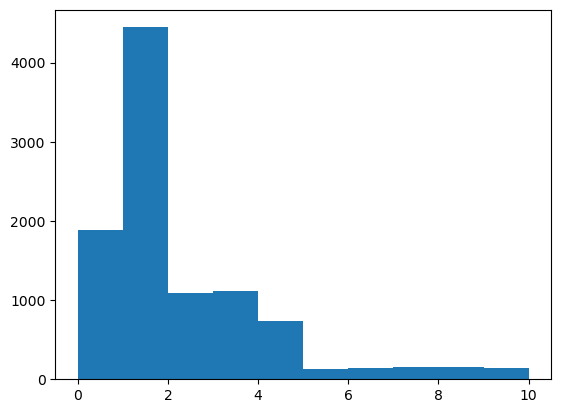

In [368]:
plt.hist(med['Children'])

In [370]:
#Still positivly skewed and the standard deviation did not change very much, so will say that it worked 

In [372]:
med.Age.describe() 

count    10000.000000
mean        53.295676
std         17.993375
min         18.000000
25%         41.000000
50%         53.295676
75%         65.000000
max         89.000000
Name: Age, dtype: float64

(array([ 823.,  761.,  746.,  753., 3160.,  739.,  730.,  765.,  710.,
         813.]),
 array([18. , 25.1, 32.2, 39.3, 46.4, 53.5, 60.6, 67.7, 74.8, 81.9, 89. ]),
 <BarContainer object of 10 artists>)

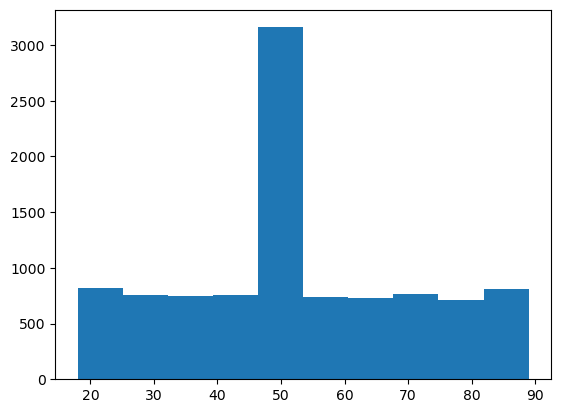

In [374]:
plt.hist(med['Age'])

In [376]:
#Still uniformish 

In [378]:
med.Income.describe() 

count     10000.000000
mean      38872.450471
std       25042.796229
min         154.080000
25%       23956.162500
50%       33942.280000
75%       46466.797500
max      207249.130000
Name: Income, dtype: float64

(array([2068., 4990., 1532.,  790.,  340.,  156.,   67.,   34.,   12.,
          11.]),
 array([1.54080000e+02, 2.08635850e+04, 4.15730900e+04, 6.22825950e+04,
        8.29921000e+04, 1.03701605e+05, 1.24411110e+05, 1.45120615e+05,
        1.65830120e+05, 1.86539625e+05, 2.07249130e+05]),
 <BarContainer object of 10 artists>)

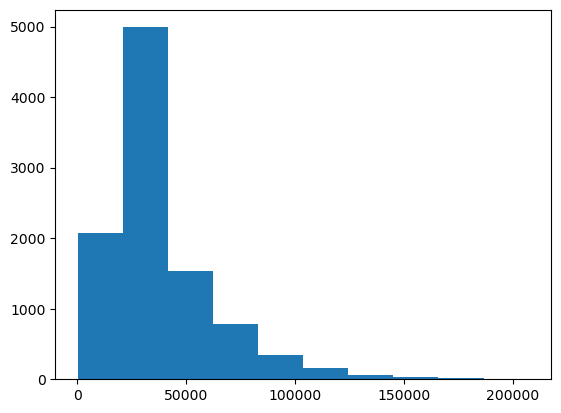

In [380]:
plt.hist(med['Income'])

In [382]:
#Still positivly skewed, so it worked

In [384]:
med.Initial_days.describe() 

count    10000.000000
mean        34.433651
std         24.860232
min          1.001981
25%          8.928987
50%         34.446941
75%         59.459981
max         71.981486
Name: Initial_days, dtype: float64

(array([2288., 1429.,  599.,  134., 1088.,  235.,  502.,  916., 1314.,
        1495.]),
 array([ 1.00198092,  8.09993146, 15.197882  , 22.29583253, 29.39378307,
        36.49173361, 43.58968415, 50.68763469, 57.78558522, 64.88353576,
        71.9814863 ]),
 <BarContainer object of 10 artists>)

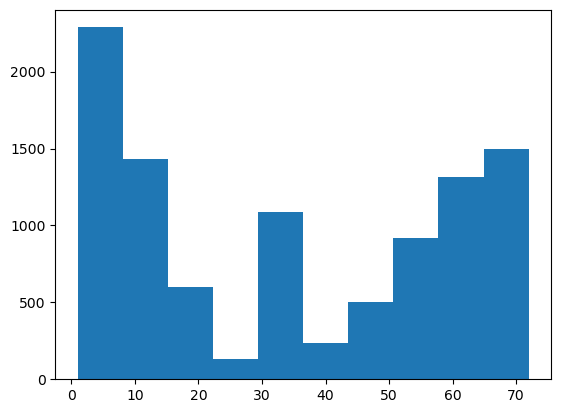

In [386]:
plt.hist(med['Initial_days'])

In [77]:
med.isnull().sum() #Seeing what other null variables there are 

Unnamed: 0               0
CaseOrder                0
Customer_id              0
Interaction              0
UID                      0
City                     0
State                    0
County                   0
Zip                      0
Lat                      0
Lng                      0
Population               0
Area                     0
Timezone                 0
Job                      0
Children                 0
Age                      0
Education                0
Employment               0
Income                   0
Marital                  0
Gender                   0
ReAdmis                  0
VitD_levels              0
Doc_visits               0
Full_meals_eaten         0
VitD_supp                0
Soft_drink            2467
Initial_admin            0
HighBlood                0
Stroke                   0
Complication_risk        0
Overweight             982
Arthritis                0
Diabetes                 0
Hyperlipidemia           0
BackPain                 0
A

In [388]:
#Filling the categorical variables with 'None'

In [390]:
null_rows['Soft_drink'] = med.fillna({'Soft_drink': 'None' }, inplace=True)

In [392]:
null_rows['Overweight'] = med.fillna({'Overweight': 'None' }, inplace=True)

In [394]:
null_rows['Anxiety'] = med.fillna({'Anxiety': 'None' }, inplace=True)

In [396]:
med.isnull().sum()
#Final check for any missing variables

Unnamed: 0            0
CaseOrder             0
Customer_id           0
Interaction           0
UID                   0
City                  0
State                 0
County                0
Zip                   0
Lat                   0
Lng                   0
Population            0
Area                  0
Timezone              0
Job                   0
Children              0
Age                   0
Education             0
Employment            0
Income                0
Marital               0
Gender                0
ReAdmis               0
VitD_levels           0
Doc_visits            0
Full_meals_eaten      0
VitD_supp             0
Soft_drink            0
Initial_admin         0
HighBlood             0
Stroke                0
Complication_risk     0
Overweight            0
Arthritis             0
Diabetes              0
Hyperlipidemia        0
BackPain              0
Anxiety               0
Allergic_rhinitis     0
Reflux_esophagitis    0
Asthma                0
Services        

In [398]:
#Looks good

**Finding and dealing with outliers**

(array([1880., 4446., 1094., 1113.,  739.,  126.,  145.,  154.,  157.,
         146.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.]),
 <BarContainer object of 10 artists>)

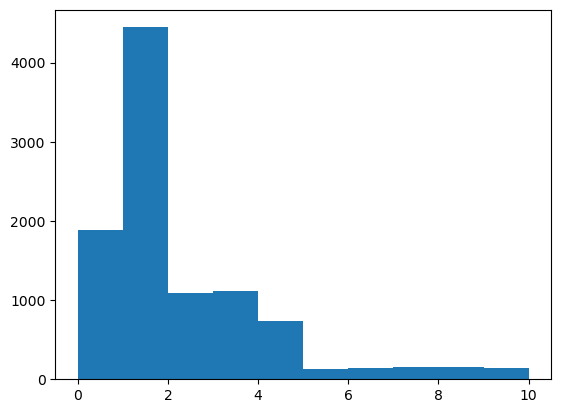

In [401]:
#First gonna get an idea on how the float numerical values are distributed  
plt.hist(med['Children'])

<Axes: xlabel='Children'>

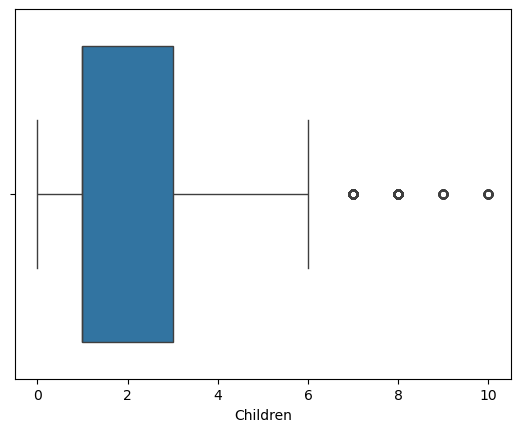

In [403]:
sns.boxplot(x = 'Children', data= med)

In [405]:
med['Children'].describe()

count    10000.000000
mean         1.814000
std          1.916969
min          0.000000
25%          1.000000
50%          1.000000
75%          3.000000
max         10.000000
Name: Children, dtype: float64

(array([ 823.,  761.,  746.,  753., 3160.,  739.,  730.,  765.,  710.,
         813.]),
 array([18. , 25.1, 32.2, 39.3, 46.4, 53.5, 60.6, 67.7, 74.8, 81.9, 89. ]),
 <BarContainer object of 10 artists>)

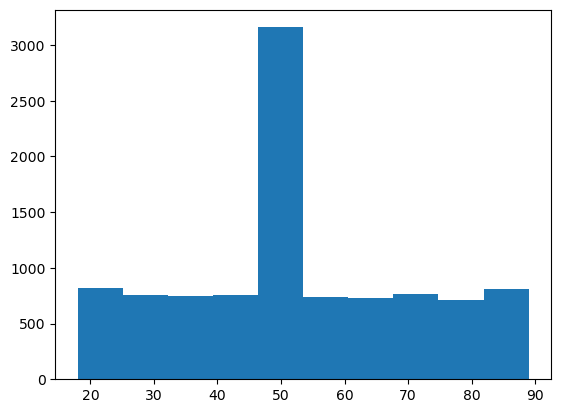

In [407]:
plt.hist(med['Age'])

<Axes: xlabel='Age'>

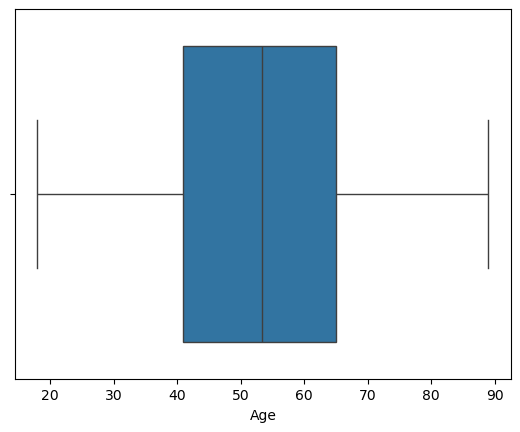

In [408]:
sns.boxplot(x = 'Age', data= med)

In [410]:
med['Age'].describe()

count    10000.000000
mean        53.295676
std         17.993375
min         18.000000
25%         41.000000
50%         53.295676
75%         65.000000
max         89.000000
Name: Age, dtype: float64

(array([2068., 4990., 1532.,  790.,  340.,  156.,   67.,   34.,   12.,
          11.]),
 array([1.54080000e+02, 2.08635850e+04, 4.15730900e+04, 6.22825950e+04,
        8.29921000e+04, 1.03701605e+05, 1.24411110e+05, 1.45120615e+05,
        1.65830120e+05, 1.86539625e+05, 2.07249130e+05]),
 <BarContainer object of 10 artists>)

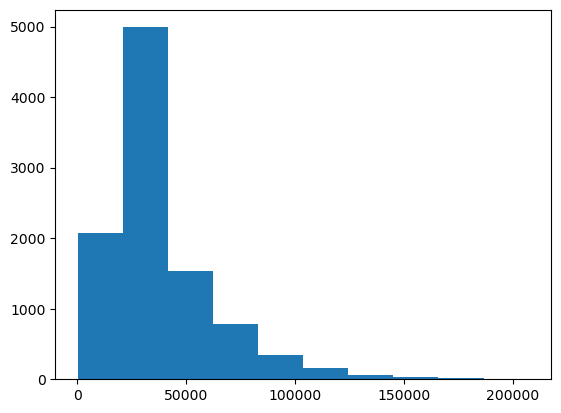

In [413]:
plt.hist(med['Income'])

<Axes: xlabel='Income'>

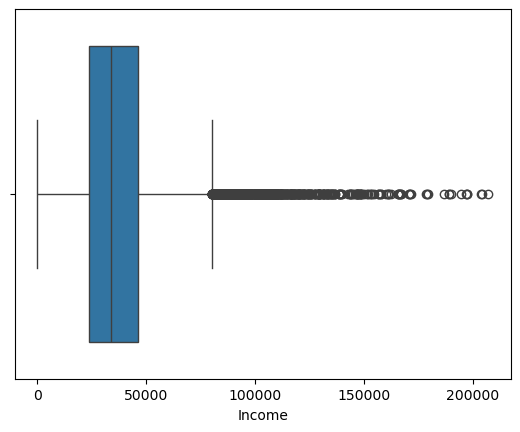

In [415]:
sns.boxplot(x = 'Income', data= med)

In [417]:
med['Income'].describe()

count     10000.000000
mean      38872.450471
std       25042.796229
min         154.080000
25%       23956.162500
50%       33942.280000
75%       46466.797500
max      207249.130000
Name: Income, dtype: float64

(array([ 313., 4930., 4063.,  194.,    0.,    0.,    0.,   49.,  329.,
         122.]),
 array([ 9.51901164, 13.86902289, 18.21903414, 22.56904539, 26.91905665,
        31.2690679 , 35.61907915, 39.9690904 , 44.31910166, 48.66911291,
        53.01912416]),
 <BarContainer object of 10 artists>)

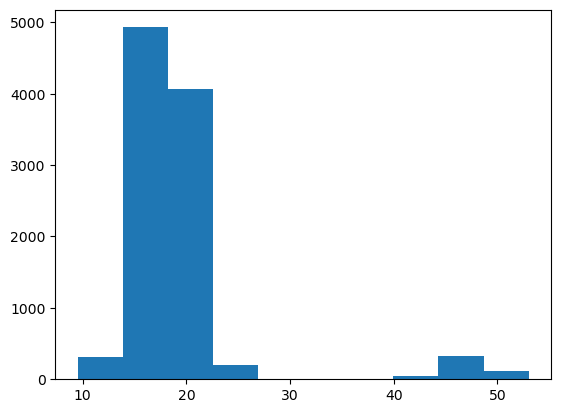

In [419]:
plt.hist(med['VitD_levels'])

<Axes: xlabel='VitD_levels'>

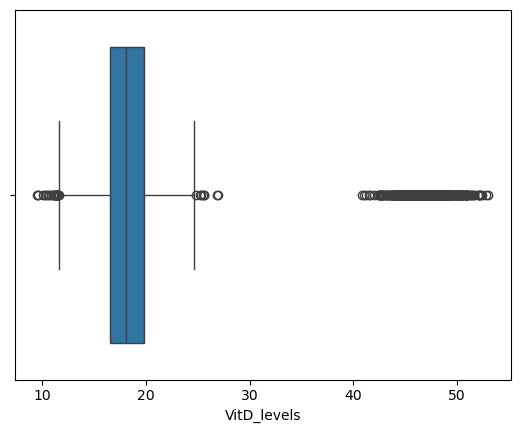

In [421]:
sns.boxplot(x = 'VitD_levels', data= med)

In [423]:
med['VitD_levels'].describe()

count    10000.000000
mean        19.412675
std          6.723277
min          9.519012
25%         16.513171
50%         18.080560
75%         19.789740
max         53.019124
Name: VitD_levels, dtype: float64

(array([2288., 1429.,  599.,  134., 1088.,  235.,  502.,  916., 1314.,
        1495.]),
 array([ 1.00198092,  8.09993146, 15.197882  , 22.29583253, 29.39378307,
        36.49173361, 43.58968415, 50.68763469, 57.78558522, 64.88353576,
        71.9814863 ]),
 <BarContainer object of 10 artists>)

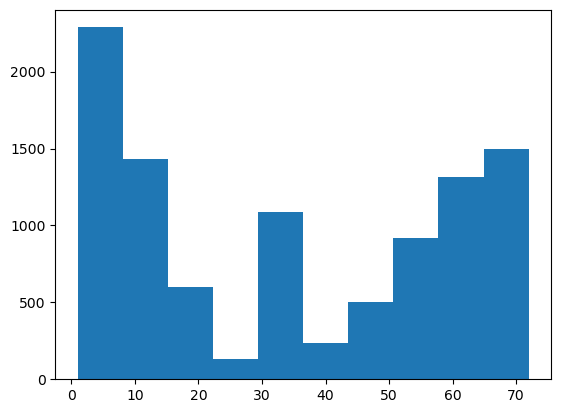

In [425]:
plt.hist(med['Initial_days'])

<Axes: xlabel='Initial_days'>

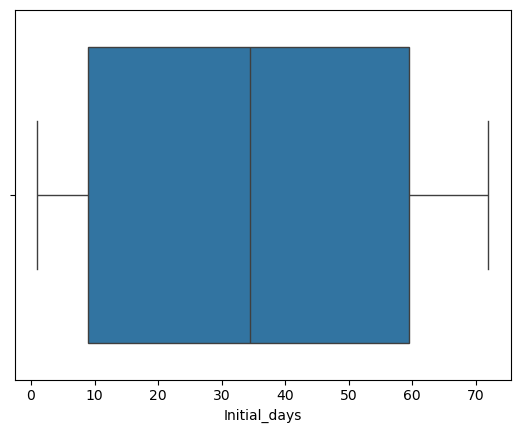

In [427]:
sns.boxplot(x = 'Initial_days', data= med)

In [429]:
med['Initial_days'].describe()

count    10000.000000
mean        34.433651
std         24.860232
min          1.001981
25%          8.928987
50%         34.446941
75%         59.459981
max         71.981486
Name: Initial_days, dtype: float64

(array([2587., 2204., 2136., 2553.,   20.,    5.,  187.,   63.,  167.,
          78.]),
 array([ 1256.751699 ,  3283.4989501,  5310.2462012,  7336.9934523,
         9363.7407034, 11390.4879545, 13417.2352056, 15443.9824567,
        17470.7297078, 19497.4769589, 21524.22421  ]),
 <BarContainer object of 10 artists>)

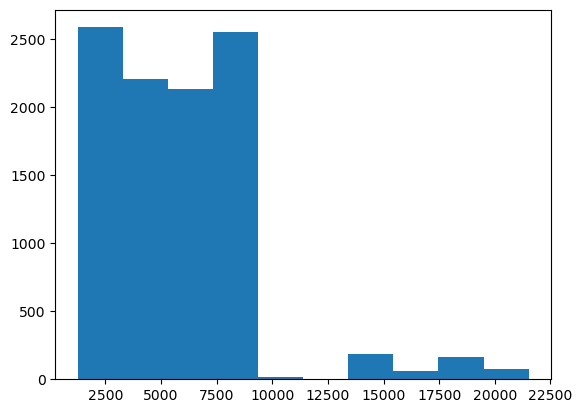

In [431]:
plt.hist(med['TotalCharge'])

<Axes: xlabel='TotalCharge'>

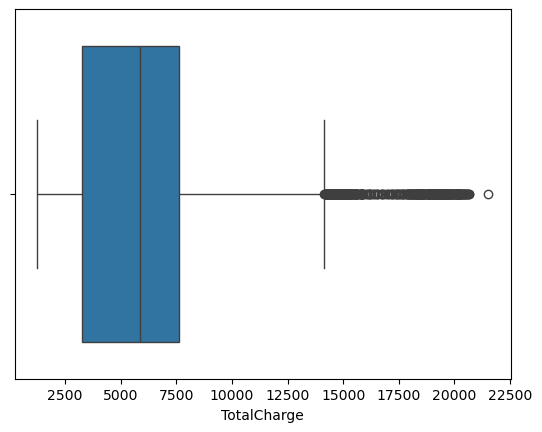

In [433]:
sns.boxplot(x = 'TotalCharge', data= med)

In [435]:
med['TotalCharge'].describe()

count    10000.000000
mean      5891.538261
std       3377.558136
min       1256.751699
25%       3253.239465
50%       5852.250564
75%       7614.989701
max      21524.224210
Name: TotalCharge, dtype: float64

(array([1120., 1818., 1891., 1856., 1032.,  497.,  494.,  507.,  487.,
         298.]),
 array([ 3125.702716 ,  5869.7397574,  8613.7767988, 11357.8138402,
        14101.8508816, 16845.887923 , 19589.9249644, 22333.9620058,
        25077.9990472, 27822.0360886, 30566.07313  ]),
 <BarContainer object of 10 artists>)

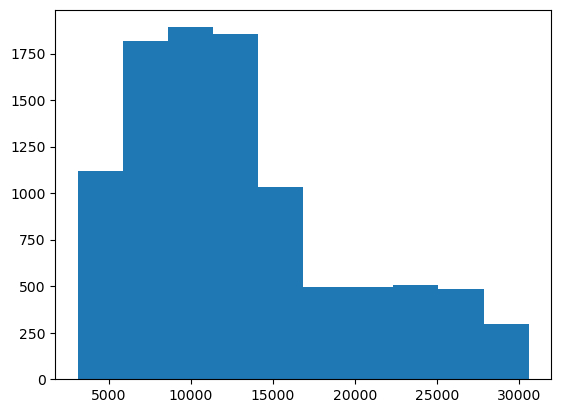

In [437]:
plt.hist(med['Additional_charges'])

<Axes: xlabel='Additional_charges'>

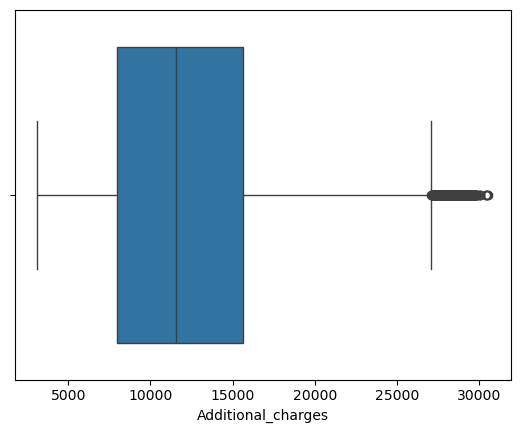

In [439]:
sns.boxplot(x = 'Additional_charges', data= med)

In [441]:
med['Additional_charges'].describe()

count    10000.000000
mean     12934.528586
std       6542.601544
min       3125.702716
25%       7986.487642
50%      11573.979365
75%      15626.491033
max      30566.073130
Name: Additional_charges, dtype: float64

In [443]:
#Imputing the VitD_Level outliers
med['VitD_levels'] = np.where(med['VitD_levels'] > 40, np.nan, med['VitD_levels'])

In [445]:
med.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 53 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          10000 non-null  int64  
 1   CaseOrder           10000 non-null  int64  
 2   Customer_id         10000 non-null  object 
 3   Interaction         10000 non-null  object 
 4   UID                 10000 non-null  object 
 5   City                10000 non-null  object 
 6   State               10000 non-null  object 
 7   County              10000 non-null  object 
 8   Zip                 10000 non-null  int64  
 9   Lat                 10000 non-null  float64
 10  Lng                 10000 non-null  float64
 11  Population          10000 non-null  int64  
 12  Area                10000 non-null  object 
 13  Timezone            10000 non-null  object 
 14  Job                 10000 non-null  object 
 15  Children            10000 non-null  float64
 16  Age  

In [447]:
null_rows = med.isnull().any(axis=1)

In [449]:
#There are now 500 nulls in VitD_level that need to be filled
null_rows['VitD_levels'] = med.fillna({'VitD_levels':med['VitD_levels'].median()}, inplace = True)

In [451]:
#Cheching to see how the imputation changed the data
med.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 53 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          10000 non-null  int64  
 1   CaseOrder           10000 non-null  int64  
 2   Customer_id         10000 non-null  object 
 3   Interaction         10000 non-null  object 
 4   UID                 10000 non-null  object 
 5   City                10000 non-null  object 
 6   State               10000 non-null  object 
 7   County              10000 non-null  object 
 8   Zip                 10000 non-null  int64  
 9   Lat                 10000 non-null  float64
 10  Lng                 10000 non-null  float64
 11  Population          10000 non-null  int64  
 12  Area                10000 non-null  object 
 13  Timezone            10000 non-null  object 
 14  Job                 10000 non-null  object 
 15  Children            10000 non-null  float64
 16  Age  

(array([  14.,  115.,  576., 1740., 3292., 2427., 1368.,  398.,   63.,
           7.]),
 array([ 9.51901164, 11.25793403, 12.99685643, 14.73577882, 16.47470121,
        18.21362361, 19.952546  , 21.6914684 , 23.43039079, 25.16931319,
        26.90823558]),
 <BarContainer object of 10 artists>)

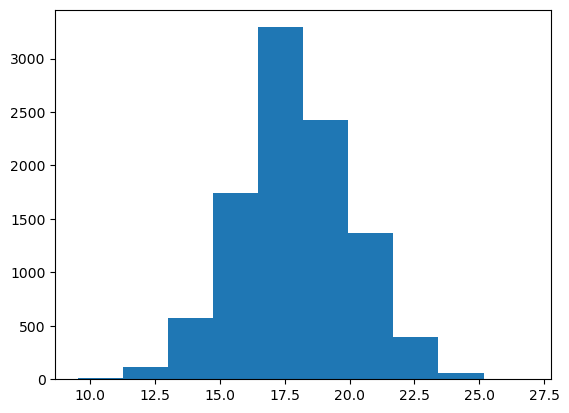

In [453]:
plt.hist(med['VitD_levels'])

<Axes: xlabel='VitD_levels'>

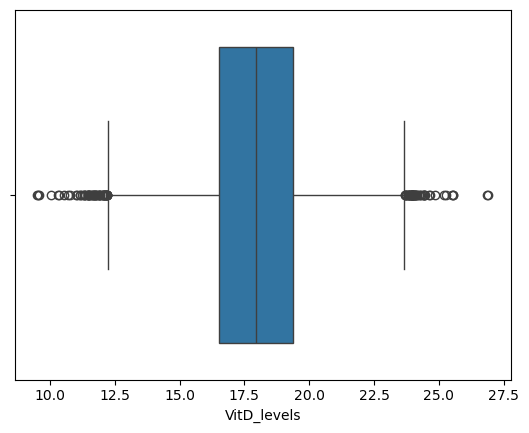

In [455]:
sns.boxplot(x = 'VitD_levels', data= med)

In [457]:
med['VitD_levels'].describe()

count    10000.000000
mean        17.958006
std          2.194158
min          9.519012
25%         16.513171
50%         17.935591
75%         19.381629
max         26.908236
Name: VitD_levels, dtype: float64

In [459]:
#this looks more reconiable 

**Extracting Clean Data**

In [462]:
med.to_csv('medical_clean_data.csv')

**PCA**

In [465]:
#Defining Variables
medical = med[['Income','VitD_levels','Initial_days','TotalCharge','Additional_charges']]

In [467]:
#Normalizing 
med_normalized = (medical-medical.mean())/medical.std()

In [469]:
#Applying PCA
pca = PCA(n_components = medical.shape[1])

In [471]:
pca.fit(med_normalized)

PCA(n_components=5)

In [473]:
#Getting the loading
loadings = pd.DataFrame(pca.components_.T,
                        columns = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5'],
                        index=medical.columns)
loadings

,PC1,PC2,PC3,PC4,PC5
Income,-0.012791,0.381539,0.814284,0.437270,-0.001133
VitD_levels,0.036730,-0.727945,-0.024046,0.680844,-0.067966
Initial_days,0.704905,0.084956,-0.019968,-0.018146,-0.703679
TotalCharge,0.707572,-0.015575,0.010774,0.016054,0.706205
Additional_charges,0.030630,-0.563084,0.579524,-0.587077,-0.038603


In [475]:
#Selecting PCs
cov_matrix = np.dot(med_normalized.T, med_normalized)/medical.shape[0]

In [477]:
eigenvalues = [np.dot(eigenvector.T, np.dot(cov_matrix, eigenvector)) for eigenvector in pca.components_]

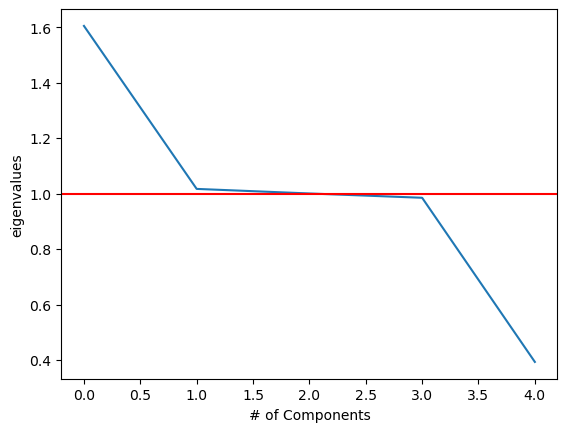

In [479]:
plt.plot(eigenvalues)
plt.xlabel('# of Components')
plt.ylabel('eigenvalues')
plt.axhline(y=1, color="red")
plt.show()

Looks like PC1-PC3 are the most meanignful because they have eigenvalues greater or equal to one. 